# Running-Speed Modulation of Mouse V1 — Unified Demo (Analyses 1–3)

This notebook demonstrates the **key result of each of three analyses** of how **running speed modulates mouse V1**, across drifting gratings (DG), static gratings (SG), and natural scenes (NS), versus spontaneous activity. The **headline cohort is V1** — the pooled **VISp** containers `511507650 / 511509529 / 511510650` (cells matched across sessions A/B, **n ≈ 363**). Every part leads with V1; **VISpm is only a control** for area-specificity.

> ⚠️ **Cohort note.** The bundled 47-cell cohort (`visual_coding_data.npz`, loaded below as `vispm`) is container **`511510753 = VISpm`**, a *higher* visual area that's not V1 (see [`doc/TEAM_NOTE.md`](doc/TEAM_NOTE.md)). It appears in this notebook **only as a labelled control**; the V1 result is the finding.

**Contents:** 
- Setup 
- Part 1 — Speed tuning (V1) 
- Part 2 — Binary running modulation (V1) 
- Part 3 — Encoding model & the two-metric result (V1) 
- Takeaway

In [1]:
# --- shared setup (runs first; every part assumes these names exist; do NOT re-import/reload) ---
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import os, glob, numpy as np, matplotlib.pyplot as plt
import utils
from utils import extract_trials, SpeedTuning, BinaryModulation, EncodingModel, RESPONSE_WINDOWS

STIM  = ["drifting_gratings", "static_gratings", "natural_scenes"]
SHORT = {"drifting_gratings": "DG", "static_gratings": "SG", "natural_scenes": "NS"}

# ===== V1 = THE SPOTLIGHT: pooled 3-container VISp cohort (n~363) =====
V1_CONTAINERS = [511507650, 511509529, 511510650]
if not glob.glob("data/container_*.npz"):
    raise FileNotFoundError(
        "V1 container files missing — fetch once (offline):\n"
        "  python scripts/download_container.py --containers 511507650 511509529 511510650 --out-dir data")
v1_containers, v1_cids = utils.load_containers("data")
print("V1 (spotlight) containers:", v1_cids)

# ===== VISpm = CONTROL ONLY: bundled 47-cell cohort (container 511510753, a higher visual area) =====
vispm = utils.load_data("data")
print("VISpm (control) cells:", np.asarray(vispm["matched_cell_ids"]).size)

V1 (spotlight) containers: [511507650, 511509529, 511510650]


VISpm (control) cells: 47


## Part 1 — Speed tuning (V1)

For every V1 neuron we bin its trials by running speed, build a **speed-tuning curve** (mean ΔF/F per bin), then ask two questions:

1. **Is the neuron speed-tuned?** One-way **ANOVA** across the speed bins (`significance_test` → `anova_p_values`, `significant_mask`, p < 0.05).
2. **Is the tuning monotonic?** **Spearman ρ** between response and speed (`compute_spearman` → `rho`, `monotonic_mask`: *positive* / *negative* / *non-monotonic*).

We fit `SpeedTuning` per container over `v1_containers` (`neuron_mask=None`, so counts are over the **full** V1 population) and pool the three VISp containers; VISpm appears afterward as a short area control.

In [2]:
# --- SpeedTuning per V1 container, then pool (V1 = spotlight) ---
# For each container: bin by speed -> tuning curve -> ANOVA -> Spearman.
# neuron_mask=None => significance / monotonicity are over the FULL population.
v1_tunings = []                       # list of {stim: SpeedTuning} per container
for st_data, st_cid in zip(v1_containers, v1_cids):
    st_tun = {}
    for stim in STIM:
        st_obj = SpeedTuning(extract_trials(st_data, stimulus=stim),
                             mode="equal_size", n_bins=20)
        st_obj.run()                  # compute_tuning + significance_test + compute_spearman
        st_tun[stim] = st_obj
    v1_tunings.append(st_tun)
    print(f"container {st_cid} (n={len(st_data['matched_cell_ids'])}): "
          + ", ".join(f"{SHORT[s]} tuned {int(st_tun[s].significant_mask.sum())}" for s in STIM))

# Pool per-cell curves onto a common speed grid + sum tuned / monotonicity counts
st_N_BINS = 20
st_grids  = {s: np.linspace(min(t[s].bins_centers[0]  for t in v1_tunings),
                            max(t[s].bins_centers[-1] for t in v1_tunings), st_N_BINS)
             for s in STIM}
st_curves = {s: [] for s in STIM}
st_counts = {s: {"positive": 0, "negative": 0, "non-monotonic": 0} for s in STIM}
st_sig    = {s: 0 for s in STIM}
for st_tun in v1_tunings:
    for stim in STIM:
        t, grid, ob = st_tun[stim], st_grids[stim], st_tun[stim].bins_centers
        for ci in range(t.mean_all_responses.shape[0]):
            y = t.mean_all_responses[ci]
            if np.all(np.isnan(y)):
                continue
            ny = np.interp(grid, ob, y)
            ny[(grid < ob[0]) | (grid > ob[-1])] = np.nan
            st_curves[stim].append(ny)
        st_sig[stim] += int(t.significant_mask.sum())
        for c in st_counts[stim]:
            st_counts[stim][c] += int(t.monotonic_mask[c].sum())
v1_total = sum(len(d["matched_cell_ids"]) for d in v1_containers)
print(f"\nPooled V1: {len(v1_cids)} container(s), n={v1_total} neurons")

container 511507650 (n=63): DG tuned 40, SG tuned 44, NS tuned 41


container 511509529 (n=116): DG tuned 30, SG tuned 29, NS tuned 52


container 511510650 (n=67): DG tuned 7, SG tuned 19, NS tuned 20

Pooled V1: 3 container(s), n=246 neurons


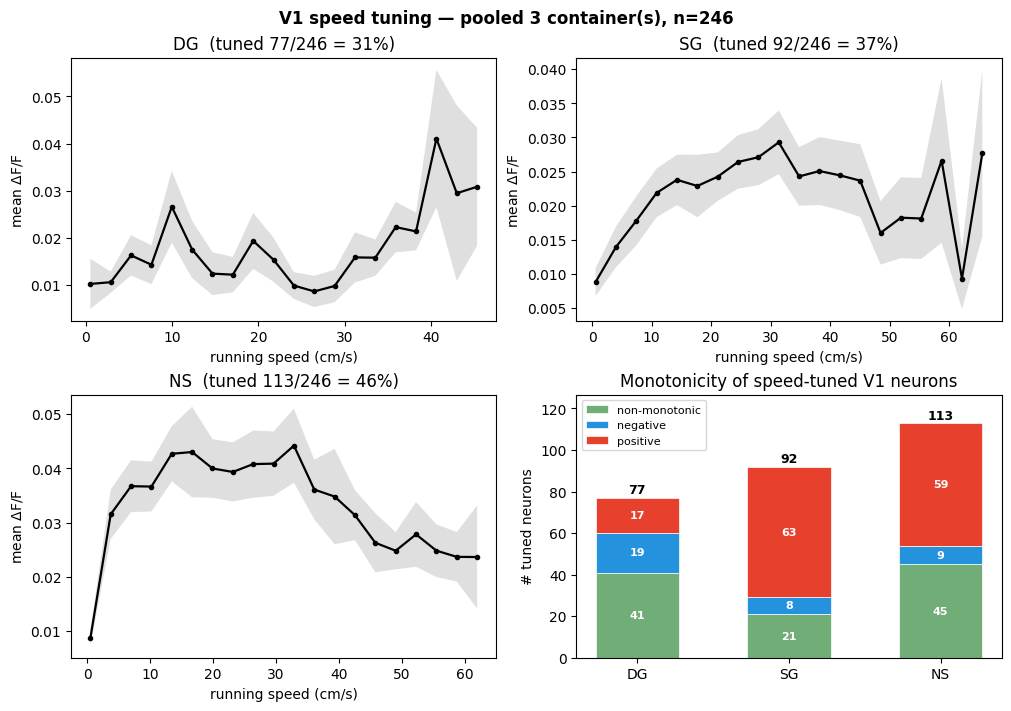

DG: tuned 77/246 (31.3%)  |  positive 17  negative 19  non-monotonic 41
SG: tuned 92/246 (37.4%)  |  positive 63  negative 8  non-monotonic 21
NS: tuned 113/246 (45.9%)  |  positive 59  negative 9  non-monotonic 45


In [3]:
# --- V1 spotlight figure: pooled tuning curves + monotonicity of tuned cells ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
for j, stim in enumerate(STIM):
    ax  = axes.flat[j]
    arr = np.array(st_curves[stim])
    mu  = np.nanmean(arr, 0)
    nv  = np.sum(~np.isnan(arr), 0)
    sem = np.nanstd(arr, 0, ddof=0) / np.sqrt(nv.clip(min=1))
    ax.fill_between(st_grids[stim], mu - sem, mu + sem, color="gray", alpha=0.25, edgecolor="none")
    ax.plot(st_grids[stim], mu, color="k", lw=1.6, marker="o", ms=3)
    ax.set_title(f"{SHORT[stim]}  (tuned {st_sig[stim]}/{v1_total} = {st_sig[stim]/v1_total:.0%})")
    ax.set_xlabel("running speed (cm/s)"); ax.set_ylabel("mean $\\Delta$F/F")

ax   = axes.flat[3]
cats = ["non-monotonic", "negative", "positive"]
cmap = {"positive": utils.POS_COLOR, "negative": utils.NEG_COLOR, "non-monotonic": utils.NM_COLOR}
x    = np.arange(len(STIM)); bottom = np.zeros(len(STIM))
for cat in cats:
    vals = [st_counts[s][cat] for s in STIM]
    ax.bar(x, vals, 0.55, bottom=bottom, color=cmap[cat], edgecolor="white", lw=0.5, label=cat)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(i, bottom[i] + v / 2, str(int(v)), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals
for i, s in enumerate(STIM):
    ax.text(i, bottom[i] + 0.5, str(st_sig[s]), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STIM]); ax.set_ylabel("# tuned neurons")
ax.legend(fontsize=8); ax.set_title("Monotonicity of speed-tuned V1 neurons"); ax.margins(y=0.12)
fig.suptitle(f"V1 speed tuning — pooled {len(v1_cids)} container(s), n={v1_total}", fontweight="bold")
plt.show()

# key V1 numbers
for s in STIM:
    c = st_counts[s]
    print(f"{SHORT[s]}: tuned {st_sig[s]}/{v1_total} ({st_sig[s]/v1_total:.1%})  |  "
          f"positive {c['positive']}  negative {c['negative']}  non-monotonic {c['non-monotonic']}")

### Area control (brief): VISpm

`vispm` (container 511510753, a **higher** visual area, n≈47) is not the result, it is shown only to check that the strong V1 speed tuning is area-specific. Same ANOVA test, reported as a fraction-tuned comparison against V1.

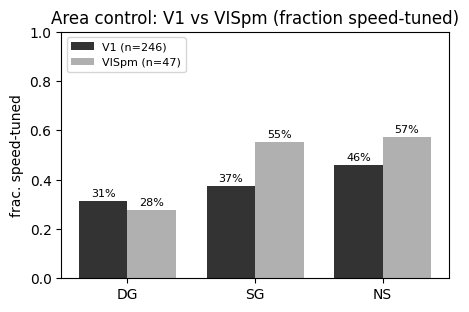

DG: V1 77/246 (31%)  vs  VISpm 13/47 (28%)
SG: V1 92/246 (37%)  vs  VISpm 26/47 (55%)
NS: V1 113/246 (46%)  vs  VISpm 27/47 (57%)


In [4]:
# --- Area control (brief): same tuned-fraction test on the VISpm cohort ---
vispm_n   = int(np.asarray(vispm["matched_cell_ids"]).size)
vispm_sig = {}
for stim in STIM:
    st_c = SpeedTuning(extract_trials(vispm, stimulus=stim), mode="equal_size", n_bins=20)
    st_c.run()
    vispm_sig[stim] = int(st_c.significant_mask.sum())

v1_frac = [st_sig[s] / v1_total for s in STIM]
pm_frac = [vispm_sig[s] / vispm_n for s in STIM]
fig, ax = plt.subplots(figsize=(5, 3.2)); x = np.arange(len(STIM)); w = 0.38
ax.bar(x - w/2, v1_frac, w, color="#333333", label=f"V1 (n={v1_total})")
ax.bar(x + w/2, pm_frac, w, color="#B0B0B0", label=f"VISpm (n={vispm_n})")
for i, (a, b) in enumerate(zip(v1_frac, pm_frac)):
    ax.text(i - w/2, a + .01, f"{a:.0%}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, b + .01, f"{b:.0%}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STIM]); ax.set_ylim(0, 1)
ax.set_ylabel("frac. speed-tuned"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("Area control: V1 vs VISpm (fraction speed-tuned)")
plt.show()
for s in STIM:
    print(f"{SHORT[s]}: V1 {st_sig[s]}/{v1_total} ({st_sig[s]/v1_total:.0%})  vs  "
          f"VISpm {vispm_sig[s]}/{vispm_n} ({vispm_sig[s]/vispm_n:.0%})")

## Part 2 — Binary running modulation (V1)

Each trial is labelled **running** or **still** from its running-speed trace, then per cell we compute a **sign-safe Modulation Index** $MI=\dfrac{R_{run}-R_{still}}{|R_{run}|+|R_{still}|+\epsilon}\in[-1,1]$ (bounded, $\mathrm{sign}(MI)=\mathrm{sign}(R_{run}-R_{still})$). Significance is a **paired t-test on condition-level $(R_{run},R_{still})$ pairs** (controls for stimulus identity), and the condition-level **gain model** $R_{run}=a\,R_{still}+b$ separates multiplicative ($a$) from additive ($b$) modulation.

In [5]:
# Run the binary running/still pipeline per V1 container, then pool per-cell results.
# (uses the shared-setup names: v1_containers, v1_cids, RESPONSE_WINDOWS, STIM, SHORT)
bm_all = [utils.run_binary_modulation_analysis(d, RESPONSE_WINDOWS) for d in v1_containers]
bm_total_cells = sum(len(d["matched_cell_ids"]) for d in v1_containers)

# Running/still trial split per container (sanity check)
for bm, cid in zip(bm_all, v1_cids):
    s = utils.summarize_binary_modulation_runs(bm)
    print(f"--- container {cid} ---")
    print(s[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]].to_string(index=False))

# Pool per-cell arrays (MI, gain, modulated_mask, ...) across the 3 containers
bm_pooled  = utils.pool_binary_modulation(bm_all)
bm_modmask = {stim: bm_pooled[stim].modulated_mask for stim in STIM}
print(f"\nPooled V1: {bm_total_cells} matched cells across containers {v1_cids}")

--- container 511507650 ---
         stimulus  n_trials  n_running  n_still  n_ignored
drifting_gratings       598         20       29        549
  static_gratings      5804       5611       22        171
   natural_scenes      5900       5332      144        424
      spontaneous      1184        968       23        193
--- container 511509529 ---
         stimulus  n_trials  n_running  n_still  n_ignored
drifting_gratings       598        169      337         92
  static_gratings      5804       1769     3742        293
   natural_scenes      5900       2278     3352        270
      spontaneous       642        291      306         45
--- container 511510650 ---
         stimulus  n_trials  n_running  n_still  n_ignored
drifting_gratings       598         35      489         74
  static_gratings      5806        215     5220        371
   natural_scenes      5900        181     5128        591
      spontaneous       642          0      635          7

Pooled V1: 246 matched cells a

### How many V1 neurons are significantly running-modulated?
Modulated = paired t-test p < 0.05 on condition-level running-vs-still response pairs.

DG: 46/246 modulated   (median MI = +0.190)
SG: 123/246 modulated   (median MI = +0.480)
NS: 159/246 modulated   (median MI = +0.422)
union (modulated in >=1 visual stimulus): 195/246


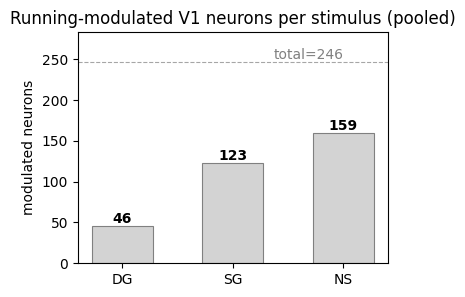

In [6]:
# Count significantly running-modulated V1 neurons per stimulus + union across visual stimuli
bm_union = np.zeros(len(bm_modmask[STIM[0]]), dtype=bool)
for stim in STIM:
    m = np.asarray(bm_modmask[stim], dtype=bool)
    bm_union |= m
    print(f"{SHORT[stim]}: {int(m.sum())}/{len(m)} modulated   (median MI = {np.nanmedian(bm_pooled[stim].mi):+.3f})")
print(f"union (modulated in >=1 visual stimulus): {int(bm_union.sum())}/{bm_total_cells}")

bm_ax = utils.plot_modulated_counts(bm_modmask, total_cells=bm_total_cells)
bm_ax.set_title("Running-modulated V1 neurons per stimulus (pooled)")
plt.show()

### Sign-safe MI distribution across DG / SG / NS, pooled V1
Grey = whole population; red overlay = running-modulated cells. Dashed lines mark medians.

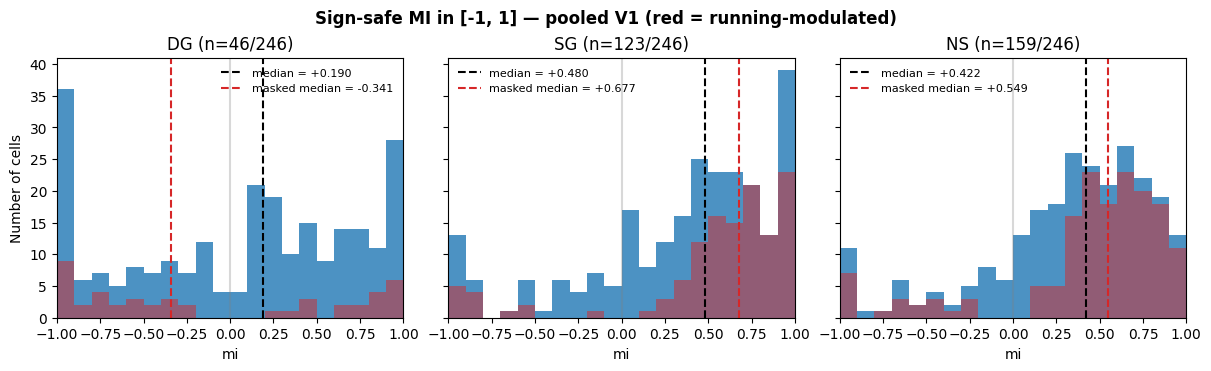

In [7]:
# Sign-safe MI histograms across the three visual stimuli, with modulated-cell overlay
fig, bm_axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
utils.plot_metric_comparison(bm_pooled, stimuli=STIM, metric="mi",
                             neurons_mask=bm_modmask, ax=bm_axes)
fig.suptitle("Sign-safe MI in [-1, 1] — pooled V1 (red = running-modulated)", fontweight="bold")
plt.show()

### Core comparison: Gratings vs natural scenes
Project headline: per matched V1 cell, grating MI = mean(DG, SG) is compared against natural-scenes MI with a paired **Wilcoxon** test. Points above the identity line = stronger running modulation for natural scenes.

                comparison  n_cells  median_grating_mi  median_natural_scene_mi  median_difference_NS_minus_grating  wilcoxon_stat  p_value  frac_NS_greater_than_grating
gratings_vs_natural_scenes      246           0.213622                 0.421771                             0.10803        11566.0 0.001178                      0.597561


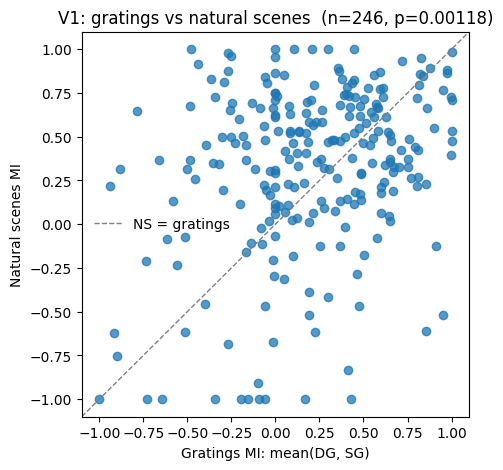

In [8]:
# HEADLINE: gratings-vs-natural MI contrast over matched V1 cells (paired Wilcoxon)
bm_gvn_df, bm_valid, bm_grating_mi, bm_natural_mi = utils.compare_gratings_vs_natural(bm_pooled)
print(bm_gvn_df.to_string(index=False))

bm_p = float(bm_gvn_df["p_value"].iloc[0])
fig, bm_ax = utils.plot_grating_natural_paired_scatter(bm_grating_mi, bm_natural_mi, p_value=bm_p)
bm_ax.set_title(f"V1: gratings vs natural scenes  (n={int(bm_gvn_df['n_cells'].iloc[0])}, p={bm_p:.3g})")
plt.show()

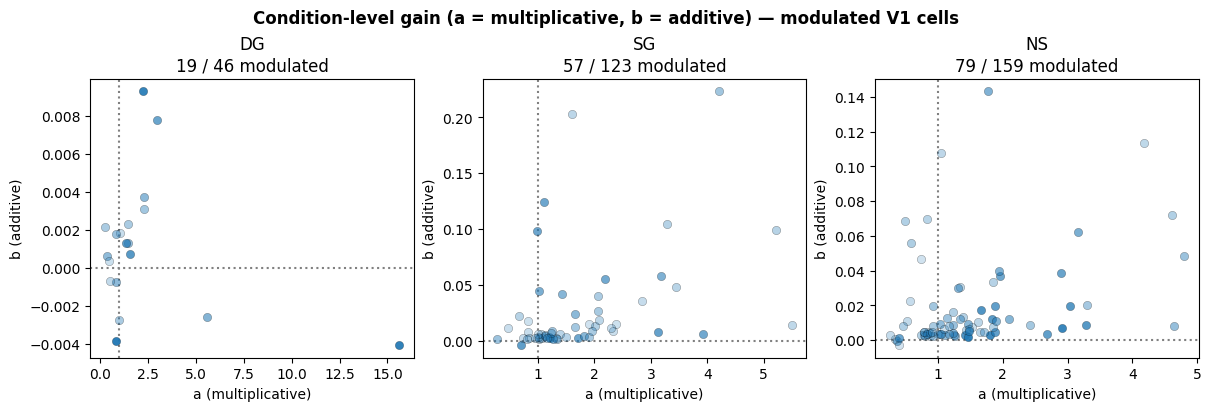

In [9]:
# Supporting mechanism: condition-level gain R_run = a*R_still + b for modulated V1 cells
# (a > 1 = multiplicative gain, b != 0 = additive offset; opacity = gain R^2)
fig = utils.plot_gain_scatter(bm_pooled, r2_threshold=0.2)
fig.suptitle("Condition-level gain (a = multiplicative, b = additive) — modulated V1 cells", fontweight="bold")
plt.show()

### Control: Area specificity (VISpm, brief)
Same pipeline on the bundled **VISpm** cohort (a higher visual area, n = 47), shown only as an area comparison; the V1 result above is the main finding.

VISpm DG: 5/47 modulated   (median MI = +0.111)
VISpm SG: 29/47 modulated   (median MI = +0.082)
VISpm NS: 30/47 modulated   (median MI = +0.279)

VISpm gratings-vs-natural:
 n_cells  median_grating_mi  median_natural_scene_mi  p_value  frac_NS_greater_than_grating
      47           0.116943                 0.278521  0.04537                      0.617021


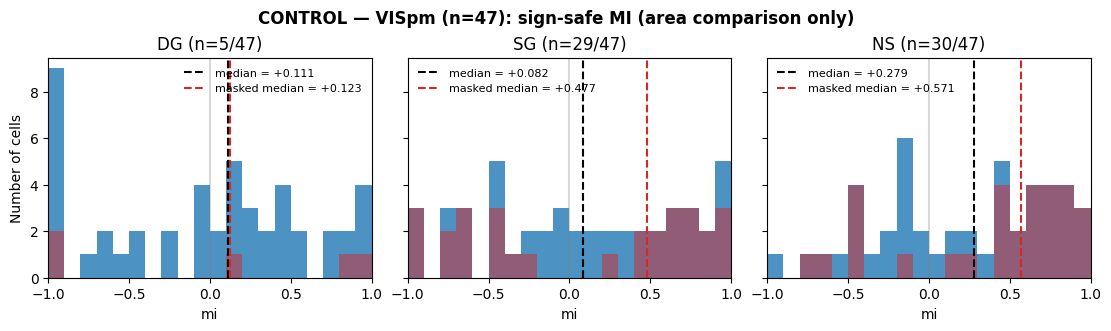

In [10]:
# CONTROL ONLY: identical binary-modulation pipeline on the VISpm cohort (`vispm`)
bm_vispm = utils.run_binary_modulation_analysis(vispm, RESPONSE_WINDOWS)
bm_vispm_modmask = {stim: bm_vispm[stim].modulated_mask for stim in STIM}
for stim in STIM:
    m = bm_vispm_modmask[stim]
    print(f"VISpm {SHORT[stim]}: {int(m.sum())}/{len(m)} modulated   (median MI = {np.nanmedian(bm_vispm[stim].mi):+.3f})")

bm_vispm_df, _, bm_vispm_g, bm_vispm_n = utils.compare_gratings_vs_natural(bm_vispm)
print("\nVISpm gratings-vs-natural:")
print(bm_vispm_df[["n_cells", "median_grating_mi", "median_natural_scene_mi", "p_value", "frac_NS_greater_than_grating"]].to_string(index=False))

fig, bm_vaxes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True, constrained_layout=True)
utils.plot_metric_comparison(bm_vispm, stimuli=STIM, metric="mi",
                             neurons_mask=bm_vispm_modmask, ax=bm_vaxes)
fig.suptitle("CONTROL — VISpm (n=47): sign-safe MI (area comparison only)", fontweight="bold")
plt.show()

## Part 3 — Encoding model & the two-metric result (V1)

Nested linear encoding model (`utils.EncodingModel`): per neuron we fit **null / add / mult / full** models with ridge and **blocked, purged cross-validation** (`gap=5`), then decompose the added, out-of-fold single-trial variance into `ΔR²_add / ΔR²_mult / ΔR²_full` (report §2–§3, [`doc/EncodingModel.md`](doc/EncodingModel.md)).

The core result is the **divergence between two metrics** on the **pooled V1 (VISp) cohort**, the 3 containers `511507650 / 511509529 / 511510650`, cells matched within each across sessions A/B, **n = 363**:

- **Population-mean running gain** (the metric the locomotion papers use): running boosts V1 responses **1.5–2.5×** (strong, monotone DG<SG<NS, area-specific).
- **Strict cross-validated single-trial ΔR²** (this model): running adds **≈ 0** — it does *not* improve out-of-fold single-trial prediction beyond stimulus tuning.

We read the committed pooled result `data/encoding_v1.npz` (per-cell ΔR² over all 3 containers) rather than re-fitting, so these cells run fast on top of the shared setup.

> **Note on cohort size.** Parts 1–2 pool **n = 246** V1 cells matched across all three sessions (A∩B∩C, via `load_containers`). Part 3 uses the committed `encoding_v1.npz` with **n = 363** cells matched across A∩B only; the encoding model needs just DG (session A) and SG/NS (session B), so it keeps cells that lack a session-C match. Both are valid pooled-VISp cohorts; they differ only in the session-matching requirement, not the area or line.

In [11]:
# Analysis 3 — supplemental imports only (utils / np / plt / EncodingModel come from the shared setup; do NOT re-import them)
from types import SimpleNamespace
from scipy.stats import wilcoxon

# ===== V1 SPOTLIGHT: committed pooled-3-container ΔR² (blocked+purged CV), n=363, dF/F metric =====
em3_Z = np.load("data/encoding_v1.npz", allow_pickle=True)
em3_n = int(em3_Z["pooled_ids"].size)                      # 363 cells across the 3 VISp containers
em3_delta = {s: (em3_Z[f"dff__{s}__add"].astype(float),
                 em3_Z[f"dff__{s}__mult"].astype(float),
                 em3_Z[f"dff__{s}__full"].astype(float)) for s in STIM}

print(f"V1 spotlight — pooled n={em3_n} cells across 3 VISp containers {V1_CONTAINERS}")
print("STRICT METRIC: cross-validated single-trial ΔR² (blocked+purged CV, dF/F)\n")
print(f"{'stim':6s}{'ΔR²_add':>11s}{'frac>0':>8s}{'p(>0)':>9s}{'ΔR²_mult':>11s}{'ΔR²_full':>11s}")
for s in STIM:
    da, dm, dfu = em3_delta[s]
    p = wilcoxon(da, alternative="greater").pvalue           # one-sided: is the added term > 0?
    print(f"{SHORT[s]:6s}{np.median(da):>+11.5f}{(da>0).mean():>8.2f}{p:>9.1g}"
          f"{np.median(dm):>+11.5f}{np.median(dfu):>+11.5f}")
print("\n-> ΔR²_add ≈ +0.0002–0.0003 at most (sg/ns; DG n.s., p=0.24); ΔR²_mult & ΔR²_full null-to-negative")
print("   every stimulus. Adding running columns yields ~0 (and for DG worsens) held-out single-trial R².")

V1 spotlight — pooled n=363 cells across 3 VISp containers [511507650, 511509529, 511510650]
STRICT METRIC: cross-validated single-trial ΔR² (blocked+purged CV, dF/F)

stim      ΔR²_add  frac>0    p(>0)   ΔR²_mult   ΔR²_full
DG       -0.00007    0.50      0.2   -0.00339   -0.00610
SG       +0.00025    0.59    1e-08   -0.00057   -0.00028
NS       +0.00029    0.59    2e-10   -0.00042   -0.00039

-> ΔR²_add ≈ +0.0002–0.0003 at most (sg/ns; DG n.s., p=0.24); ΔR²_mult & ΔR²_full null-to-negative
   every stimulus. Adding running columns yields ~0 (and for DG worsens) held-out single-trial R².


### Metrics divergence

The **same 363 cells, same signal** give a strong population-mean gain and a null single-trial ΔR². A robust shift of the response **mean** contributes ≈ 0 to **out-of-fold, per-trial** prediction on noisy calcium (report §7.3). The population gain (red, left axis) is the metric the reference papers report: Allen L0 events, spike-comparable, monotone DG<SG<NS (**1.57 / 1.72 / 2.15×**, [`doc/EncodingModel.md`](doc/EncodingModel.md) §7.1, matching Liska/Yates ≈1.40 for DG). The strict `ΔR²_full` (blue, right axis) sits on zero.

V1 population running gain (rate ratio, events): {'DG': 1.57, 'SG': 1.72, 'NS': 2.15}
  dF/F cross-check (committed encoding_v1.npz):   DG=1.85×  NS=2.96×


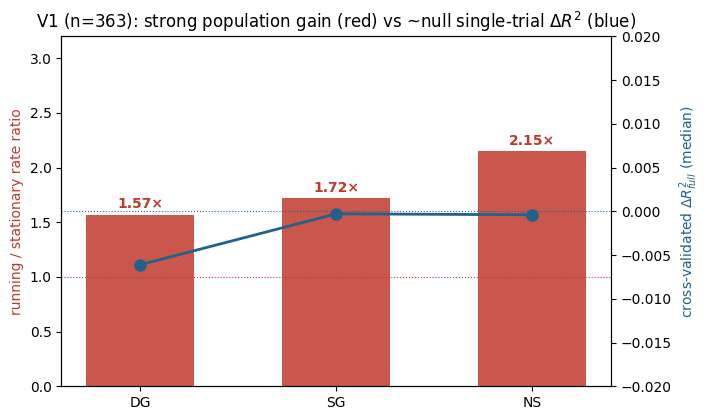

In [ ]:
# ===== SECOND METRIC: V1 population-mean running gain (run>3 vs still<0.5 cm/s), pooled n=363 =====
# Reported spike-comparable Allen L0 events (doc/EncodingModel.md §7.1, Fig.2), monotone DG<SG<NS.
em3_gain = {"drifting_gratings": 1.57, "static_gratings": 1.72, "natural_scenes": 2.15}
# committed dF/F cross-check (larger, unstable ratios per doc §7.1) — read straight from encoding_v1.npz:
em3_gain_dff = {"drifting_gratings": float(em3_Z["prim__ratio_drifting_gratings"]),
                "natural_scenes":    float(em3_Z["prim__ratio_natural_scenes"])}
print("V1 population running gain (rate ratio, events):", {SHORT[s]: em3_gain[s] for s in STIM})
print("  dF/F cross-check (committed encoding_v1.npz):   DG=%.2f×  NS=%.2f×"
      % (em3_gain_dff["drifting_gratings"], em3_gain_dff["natural_scenes"]))

# --- divergence headline figure: population gain (red) vs strict ΔR²_full (blue) ---
em3_g   = [em3_gain[s] for s in STIM]
em3_dfl = [np.median(em3_delta[s][2]) for s in STIM]
em3_x   = np.arange(len(STIM))
fig, axL = plt.subplots(figsize=(7.2, 4.3))
axL.bar(em3_x, em3_g, 0.55, color="#c0392b", alpha=0.85, zorder=2)
axL.axhline(1.0, color="#c0392b", lw=0.8, ls=":")
axL.set_ylim(0, 3.2); axL.set_ylabel("running / stationary rate ratio", color="#c0392b")
axL.set_xticks(em3_x); axL.set_xticklabels([SHORT[s] for s in STIM])
for xi, v in zip(em3_x, em3_g):
    axL.text(xi, v + 0.06, f"{v:.2f}×", ha="center", color="#c0392b", fontweight="bold")
axR = axL.twinx()
axR.plot(em3_x, em3_dfl, "o-", color="#21618c", lw=2, ms=8, zorder=3)
axR.axhline(0.0, color="#21618c", lw=0.8, ls=":")
axR.set_ylim(-0.02, 0.02); axR.set_ylabel(r"cross-validated $\Delta R^2_{full}$ (median)", color="#21618c")
axL.set_title(f"V1 (n={em3_n}): strong population gain (red) vs ~null single-trial $\\Delta R^2$ (blue)")
fig.tight_layout(); plt.show()

### ΔR² decomposition — `EncodingModel.plot_r2_decomposition()`

The built-in panel per stimulus, drawn on the **pooled n = 363** per-cell ΔR². We wrap the committed deltas in an `EncodingModel` (setting `r2_null := 0` so `r2_decomposition()` returns exactly the stored ΔR²) to reuse the plotting method without re-fitting the 363-cell ridge CV. Medians (white bars) sit on zero for `add / mult / full`; for **DG** the `mult`/`full` violins skew *negative*, adding running to the short 628-trial session actively worsens held-out prediction. **Note the different y-scales** (DG has a long negative tail; SG/NS are tight around 0).

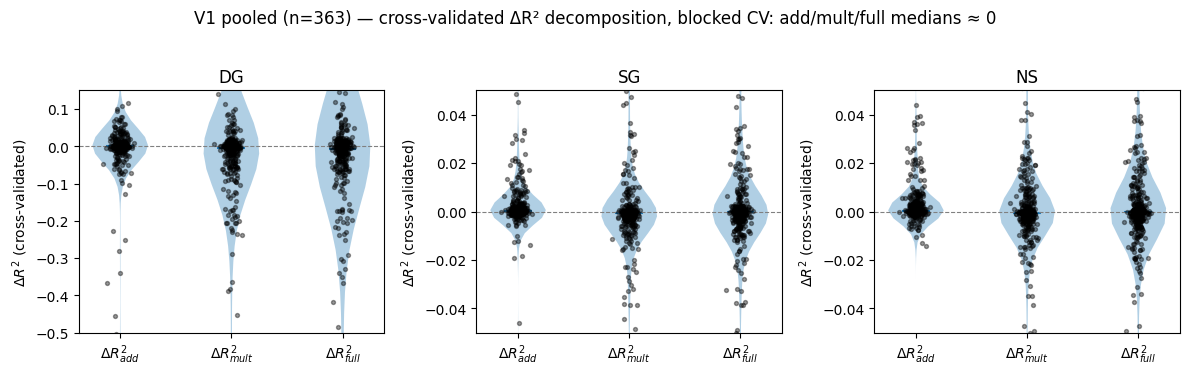

In [13]:
# Wrap the committed pooled ΔR² in an EncodingModel so the built-in plot_r2_decomposition renders the
# n=363 panels without re-fitting (r2_null:=0 => r2_decomposition() returns the stored deltas unchanged).
def em3_wrap(s):
    em = EncodingModel.__new__(EncodingModel)                # bypass __init__: we supply results directly
    da, dm, dfu = em3_delta[s]
    em.r2_null = np.zeros_like(da)
    em.r2_add, em.r2_mult, em.r2_full = da, dm, dfu
    em._td = SimpleNamespace(stimulus=SHORT[s])              # only used for the panel title
    return em

em3_ylim = {"drifting_gratings": (-0.5, 0.15),
            "static_gratings":  (-0.05, 0.05),
            "natural_scenes":   (-0.05, 0.05)}
fig, axes = plt.subplots(1, len(STIM), figsize=(12, 3.6))
for ax, s in zip(axes, STIM):
    em3_wrap(s).plot_r2_decomposition(ax=ax)                 # utils.EncodingModel.plot_r2_decomposition
    ax.set_ylim(*em3_ylim[s])
fig.suptitle(f"V1 pooled (n={em3_n}) — cross-validated ΔR² decomposition, blocked CV: add/mult/full medians ≈ 0",
             y=1.03)
fig.tight_layout(); plt.show()

### Control (area-specificity): VISpm with strict ΔR² null

Brief control on the bundled **VISpm** cohort (container `511510753`, a higher visual area; 47 cells), from the committed `data/encoding_r2.npz`. On the **strict single-trial ΔR²** VISpm is **also ~null**. The two metrics part ways only on the **population gain**: V1 ≈ 1.6–2.2× vs VISpm ≈ 1.0–1.1× (doc §7.1), so the gain is **area-specific**, while the strict ΔR² is null in *both* areas.

In [14]:
# ===== VISpm CONTROL ONLY (n=47) — committed ΔR², from data/encoding_r2.npz =====
em3_R = np.load("data/encoding_r2.npz", allow_pickle=True)   # keys inspected: cell_ids, {stim}__d_add/d_mult/d_full
print(f"VISpm control (n={int(em3_R['cell_ids'].size)}) — cross-validated ΔR² is ALSO ~null:")
for s in STIM:
    da  = em3_R[f"{s}__d_add"].astype(float)
    dfu = em3_R[f"{s}__d_full"].astype(float)
    p   = wilcoxon(da, alternative="greater").pvalue
    print(f"  {SHORT[s]:3s}  ΔR²_add median={np.median(da):+.5f} (p={p:.2g})   ΔR²_full median={np.median(dfu):+.5f}")
print("\nArea comparison on the POPULATION gain (doc §7.1):  V1 ≈ 1.6–2.2×   vs   VISpm ≈ 1.0–1.1×")
print("-> Population gain is AREA-SPECIFIC (V1 ≫ VISpm); the strict single-trial ΔR² is null in BOTH areas.")

VISpm control (n=47) — cross-validated ΔR² is ALSO ~null:
  DG   ΔR²_add median=-0.00046 (p=0.89)   ΔR²_full median=-0.00857
  SG   ΔR²_add median=-0.00009 (p=0.61)   ΔR²_full median=-0.00074
  NS   ΔR²_add median=+0.00061 (p=0.038)   ΔR²_full median=+0.00025

Area comparison on the POPULATION gain (doc §7.1):  V1 ≈ 1.6–2.2×   vs   VISpm ≈ 1.0–1.1×
-> Population gain is AREA-SPECIFIC (V1 ≫ VISpm); the strict single-trial ΔR² is null in BOTH areas.


**Takeaway (Analysis 3).** In pooled V1 (n = 363), running produces a strong, robust **population-mean gain** (rate ratio ≈ 1.5–2.5×, monotone DG<SG<NS, area-specific vs VISpm), yet the strict **cross-validated single-trial ΔR²** is ~null for every stimulus (only tiny SG/NS additive terms survive, ~0.02–0.03 % of variance). A real mean gain need not improve out-of-fold single-trial prediction on noisy calcium: the encoding ΔR² **under-reports** modulation the population metric clearly shows. Report **both** metrics: the ΔR² null is *not* biological absence (report §7.3, §9).

## Takeaway

Across all three analyses, the **pooled V1 (VISp) cohort** (containers 511507650 / 511509529 / 511510650, **n ≈ 363**) tells one coherent story; **VISpm** (container 511510753, n = 47) serves only as an area control.

- **Tuning (Part 1).** A large fraction of V1 neurons are significantly **speed-tuned** (one-way ANOVA, p < 0.05), and for SG/NS the tuning is predominantly **positive / monotonic** — responses rise with running speed. V1 is more tuned than VISpm on every stimulus (area-specific).
- **Binary modulation (Part 2).** Splitting trials running vs still, most V1 cells are significantly **running-modulated** (paired t-test), with a bounded sign-safe MI that is largest for **natural scenes** (headline paired-Wilcoxon: NS > gratings). The condition-level gain model $R_{run}=a\,R_{still}+b$ separates multiplicative ($a$) from additive ($b$) modulation.
- **Encoding model (Part 3).** The same 363 cells show a strong **population-mean running gain** (≈ 1.5–2.5×, monotone DG<SG<NS, **area-specific: V1 ≫ VISpm ≈ 1.0–1.1×**) yet a **~null cross-validated single-trial ΔR²** for every stimulus. A robust shift of the response *mean* need not improve *out-of-fold, per-trial* prediction on noisy calcium, so the encoding ΔR² **under-reports** the modulation the population metric plainly shows.

**Bottom line:** running modulates V1, visible as **tuning**, as a **binary running/still gain**, and as a **strong population-mean rate ratio**; while the strict single-trial ΔR² stays near zero. Report **both** metrics: the ΔR² null is a property of the metric, not biological absence, and the **population gain is area-specific (V1 ≫ VISpm)**. See [`doc/EncodingModel.md`](doc/EncodingModel.md) and [`doc/Modulation&Tuning.md`](doc/Modulation&Tuning.md).